# Maanav Patel's Midterm Project for COE311k

Objective: Analyze data of the GDP growth of the United States and use linear regression, polynomial fit, and cubic spline to identify the best method to predict gaps in the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Data initialization:
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56]) #Quarters since January 2010
gdp = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]) #GDP growth

Introduction: The dataset provided shows many selected quarters since 2010 Q1 and their respective GDP percent growth as arrays. The data also includes a large outlier period during 2020 and 2021 COVID-19 years. I will be analyzing the data with a linear regression, a polynomial of degree 4, and a Cubic spline. I will be answering the question to which method represents the data the best in their respective senarios.

# Part A

In [3]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n-1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))             # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a1, b1, c1, d1):
    a = a1.copy()
    b = b1.copy()
    c = c1.copy()
    d = d1.copy()
    #This makes copies of the arrays given so to not change them when running the function
    
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    x = np.insert(x, 0, 0)                        #Add a 0 at the beginning and end of the M array due to the fact that the end conditions are M0 = 0 and Mn = 0
    x = np.insert(x, len(x), 0)
    return x

def evaluate_spline(x, y, M):
    x_s = np.array([0])
    y_s = np.array([0])
    #used to give an array of all splines combined, which helps with getting specific data points without worrying about which interval the point you are looking for is in
    for i in range(len(x)-1):
        h = x[i+1] - x[i]
        x_spline = np.linspace(x[i], x[i+1], 100)
        y_spline = ((M[i] / (6 * h)) * (x[i+1] - x_spline)**3) + ((M[i+1] / (6 * h)) * (x_spline - x[i])**3) + ((y[i] / h - (M[i] * h) / 6) * (x[i+1] - x_spline)) + ((y[i+1] / h - (M[i+1] * h) / 6) * (x_spline - x[i]))     #Equation from AI
        x_s = np.append(x_s, x_spline)
        y_s = np.append(y_s, y_spline)
    return x_s, y_s

The Functions defined above are the functions for a cubic spline. For each interval between each x value, the equation axi-1 + bxi + cxi+1 = d had to be solved, which results in a matrix. Due to the nature that Cubic Splines must have matching first and second derivatives between each consecutive polynomial, the tridiagonal matrix is created to solve for these second derivitive terms, M. Since the end and beginning x values are boundary cases, M0 and Mn = 0 are added to the ends of the vector M. 

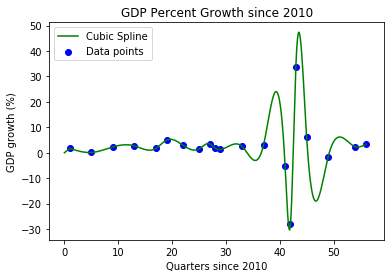

In [4]:
A, B, C, D = setup_tridiagonal_matrix(x, gdp)
M = thomas_algorithm(A[1:], B, C[:-1], D)
x_spline, y_spline = evaluate_spline(x, gdp, M)
plt.plot(x_spline, y_spline, label='Cubic Spline', color = 'green')
plt.xlabel('Quarters since 2010')
plt.ylabel('GDP growth (%)')
plt.title('GDP Percent Growth since 2010')
plt.scatter(x, gdp, label='Data points', color='blue')
plt.legend()
plt.show()

As you can see, the spline created passes through every point, is smooth, and fits the data reasonably.

Runge Phenoomenon states that as the x value of a data set under cubic spline increases, the chance of a higher degree of error from the base data points increases, especially with outlier points. This is easily seen with the -28.1 and 33.8 in 2020 Q2 and Q3 respectivly. The cublic spline predicts an even higher value than that of the data given. It shows that finding a spline for the exact data will cause less realistic predictions for values between given x intervals, giving linear regressions or polynomial fitting the upper hand in larger datasets.

# Part B

In [23]:
def residual(y, y_pred):
    return y - y_pred

In [5]:
def vandermonde_matrix(x, degree):
    n = len(x)
    V = np.zeros((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            V[i][j] = x[i] ** j
    return V

def polynomial_fit(x, y, degree):
    V = vandermonde_matrix(x, degree)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients


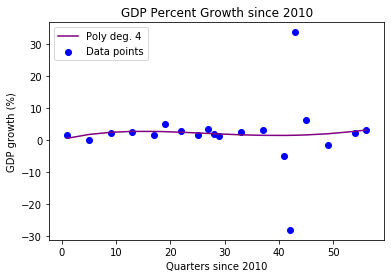

In [6]:
degree = 4
coef = polynomial_fit(x, gdp, degree)
y_poly = 0
for i in range(degree + 1):
    y_poly += coef[i] * (x**i)  #Take coefficents and put it in a polynomial function
plt.plot(x, y_poly, label='Poly deg. 4', color = 'purple')
plt.scatter(x, gdp, label='Data points', color='blue')
plt.xlabel('Quarters since 2010')
plt.ylabel('GDP growth (%)')
plt.title('GDP Percent Growth since 2010')
plt.legend()
plt.show()

(Just wanted to plot polynomial on seperate graph first as the default polynomial graph)

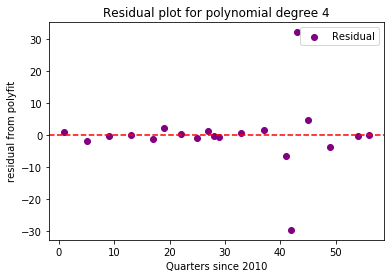

In [28]:
#Make the residual plot
y_polyres = residual(gdp, y_poly)
plt.scatter(x, y_polyres, label='Residual', color = 'purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Quarters since 2010')
plt.ylabel('residual from polyfit')
plt.title('Residual plot for polynomial degree 4')
plt.legend()
plt.show()

The residual plot may look similar to the original, but that is because the polynomial fit is already pretty close to a straight line, making the slight adjustment in the data points very small on the y-scale that I have

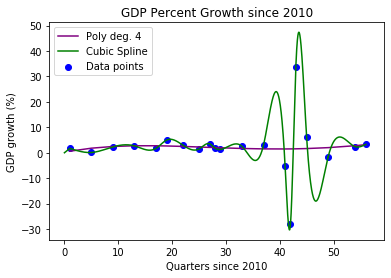

In [7]:
plt.plot(x, y_poly, label='Poly deg. 4', color = 'purple')
plt.plot(x_spline, y_spline, label='Cubic Spline', color = 'green')
plt.scatter(x, gdp, label='Data points', color='blue')
plt.xlabel('Quarters since 2010')
plt.ylabel('GDP growth (%)')
plt.title('GDP Percent Growth since 2010')
plt.legend()
plt.show()

While the Polynomial captures the overall trend of the data (No Runge phenomenon). However, the Cubic Spline is better at catching specific data points, especially with the large outliers in the data. This shows that approximation is better than interpolation when dealing with outliers.

In [8]:
x_exclude = np.append(x[0:13], x[17:])
gdp_exclude = np.append(gdp[0:13], gdp[17:])

In [9]:
def linreg(x, y):
    x.sort()
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    y_line = m*x + c
    return m, c, y_line

In [10]:
m, c, y_line = linreg(x_exclude, gdp_exclude)

In [11]:
print(m, c)

-0.0019069881889764002 2.194285187007875


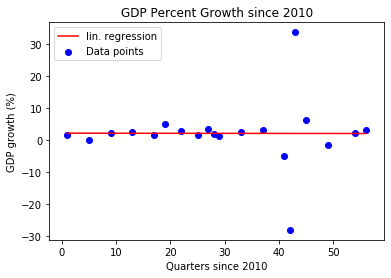

In [25]:
plt.plot(x_exclude, y_line, label='lin. regression', color='red')
plt.scatter(x, gdp, label='Data points', color='blue')
plt.xlabel('Quarters since 2010')
plt.ylabel('GDP growth (%)')
plt.title('GDP Percent Growth since 2010')
plt.legend()
plt.show()

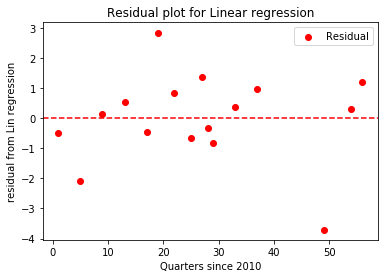

In [31]:
#Make the residual plot
y_linres = residual(gdp_exclude, y_line)
plt.scatter(x_exclude, y_linres, label='Residual', color = 'red')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Quarters since 2010')
plt.ylabel('residual from Lin regression')
plt.title('Residual plot for Linear regression')
plt.legend()
plt.show()
#This graph will be zoomed in on the y-axis since the residuals minus the outliers are small

Linear regression with a slope of -0.0019 over a long time scales outside of the data range does not predict future gdp very well (GDP won't be highly negative 500 years in the future). For a linear regression in this context to make economic sense, we need to assume that the gdp grows linearly in the future and that any outliers are omitted from the data. We also need to recognize that the line provided is only fit for the data provided, and any new data points will change the line.

Approximation vs Interpolation:

    Approximation, such as the polynomial or linear regression, often requires a simpler regression that does not go through all data points. It is able to account for noise and outliers well. However, between polynomial and linear regression, polynomial can include the outliers without severly changing the regression representation of the data while linear regression needed to exclude the outliers to be a good fit. Polynomial fitting is more closly related to the data, causing outliers to not make as much of a difference as linear regression would.
    
    Interpolation, like cubic spline, goes through every point, which makes it susceptible to ouliers and can overshoot as the x value grows from 0. However, it is better if used when data is noise-free and does not contain many outliers. This leads the discussion to Part C...

# Part C

In [13]:
def mse(y, y_pred):
    result = np.mean((y-y_pred)**2)
    return result
    
def rSq(y, y_pred):
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return r_squared

In [14]:
rSqPoly = rSq(gdp, y_poly)
msePoly = mse(gdp, y_poly)
rSqLin = rSq(gdp_exclude, y_line)
mseLin = mse(gdp_exclude, y_line)
print(rSqPoly, msePoly)
print(rSqLin, mseLin)

0.0035410151185396588 100.62980208981799
0.00044329440682566723 2.0827872400959646


I only did R-squared and mean squares for the polynomial and linear regressions beacuse it does not make sense to do it with Cubic Spline because these measure the "noisiness" of the data, and since Cubic spline goes through every data point, these numbers don't have any real meaning. Based on the model, both linear regression and polynomial fit had a pretty bad r-squared value, but that is beacuse of the outliers affecting the poly_fit.

SIDEQUEST:
The MSE is really high for the polynomial beacause we kept the outliers, what would it look like with the outliers removed? (Charlie gave me this challenge)

In [15]:
coef = polynomial_fit(x_exclude, gdp_exclude, 4)
y_polyEx = 0
for i in range(5):
    y_polyEx += coef[i] * (x_exclude**i)
rSqPolyEx = rSq(gdp_exclude, y_polyEx)
msePolyEx = mse(gdp_exclude, y_polyEx)

In [16]:
print(rSqPolyEx, msePolyEx)

0.40173376989480925 1.2466138872070776


Now the mse is lower than the Linear Regression mse! based on this new polynomial r-squared and mse compared to the linear regression, we can see that the polynomial fit has a much higher r-sqared and a lower mse than linear regression, showing that it is better at approximating the data.

Policymaker:

I would say to use Cubic spline to get the data from between quarters since polynomial fitting, although good at getting an overall trend, is not as sensitive to outliers. Because of this, if the Policymaker wants to know about the GDP growth in 2020 Q4 (for example), they would get a low number from polynomial fit while cubic spline would account for the fact that 2020 Q3 is an outlier. It also makes more sense that if the Policymaker asks about a quarter we have data for, the polynomial fit would not give the right number. The cubic spline is accurate to the data, has no knots (smooth) due to the matching second derivatives, and is accurate to outliers!

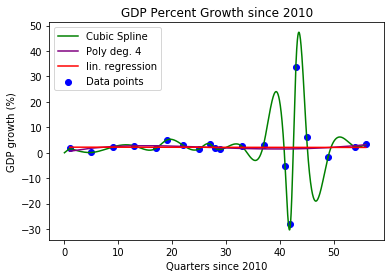

In [29]:
plt.plot(x_spline, y_spline, label='Cubic Spline', color = 'green')
plt.plot(x, y_poly, label='Poly deg. 4', color = 'purple')
plt.plot(x_exclude, y_line, label='lin. regression', color='red')
plt.xlabel('Quarters since 2010')
plt.ylabel('GDP growth (%)')
plt.title('GDP Percent Growth since 2010')
plt.scatter(x, gdp, label='Data points', color='blue')
plt.legend()
plt.show()